# Guardian Alert: Sistem Deteksi Jatuh
## 1. Penemuan Masalah & Pertanyaan Bisnis

**Pernyataan Masalah:**
Jatuh adalah penyebab utama cedera di kalangan lansia. Deteksi dan respons yang cepat dapat secara signifikan mengurangi tingkat keparahan cedera ini. Tujuan dari proyek ini adalah untuk mengembangkan model machine learning yang mampu membedakan secara akurat antara Aktivitas Kehidupan Sehari-hari (ADL) dan kejadian jatuh yang sebenarnya menggunakan data sensor Inertial Measurement Unit (IMU).

**Pertanyaan Bisnis:**
1. Pola sensor apa yang membedakan jatuh dari aktivitas normal (ADL)?
2. Sumbu/fitur sensor mana yang paling prediktif terhadap kejadian jatuh?
3. Apakah ada perbedaan pola jatuh antara subjek dewasa dan lansia?
4. Berapa set fitur minimum yang diperlukan untuk deteksi jatuh yang akurat?
5. Seberapa akurat kita dapat mendeteksi jatuh menggunakan data sensor IMU?


## 2. Data Wrangling (Pengumpulan, Penilaian, Pembersihan)

Dataset SisFall berisi data dari 38 subjek (23 dewasa, 15 lansia) yang melakukan 19 aktivitas ADL dan 15 aktivitas Jatuh. Data dikumpulkan menggunakan 3 sensor (2 akselerometer, 1 giroskop) pada frekuensi 200 Hz.

**Langkah-langkah yang diambil:**
- Memproses file teks mentah, menangani tanda titik koma di akhir baris.
- Mengonversi nilai ADC mentah ke satuan fisik (g untuk akselerometer, deg/s untuk giroskop) berdasarkan resolusi dan rentang sensor.
- Mengambil sampel 83 file representatif untuk menyeimbangkan dataset dan mengurangi waktu pemrosesan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Memuat metadata yang telah dibersihkan
metadata_path = '../data/processed/file_metadata.csv'
if os.path.exists(metadata_path):
    metadata = pd.read_csv(metadata_path)
    display(metadata.head())


,filename,activity,subject,label,samples
0,D01_SA01_R01.txt,D01,SA01,ADL,19999
1,D02_SA01_R01.txt,D02,SA01,ADL,20000
2,D03_SA01_R01.txt,D03,SA01,ADL,20000
3,D04_SA01_R01.txt,D04,SA01,ADL,20000
4,D05_SA01_R01.txt,D05,SA01,ADL,5000


## 3. Analisis Data Eksploratif (EDA)

Kami mengeksplorasi distribusi label dan aktivitas untuk memahami keseimbangan dataset.


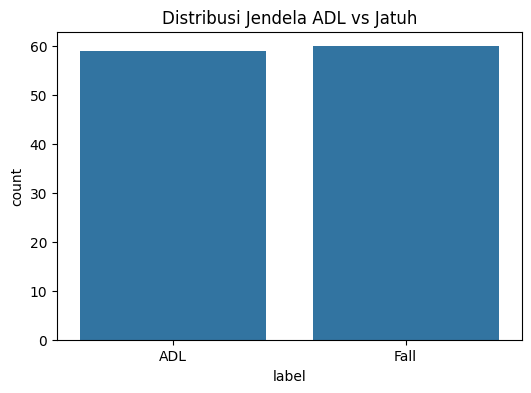

In [2]:
# Memuat fitur yang telah diekstraksi
features_path = '../data/features/features_extracted.csv'
if os.path.exists(features_path):
    df = pd.read_csv(features_path)
    
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='label')
    plt.title('Distribusi Jendela ADL vs Jatuh')
    plt.show()


## 4. Rekayasa Fitur (Feature Engineering)

Untuk menangkap sifat dinamis dari jatuh, kami mengekstraksi fitur melalui jendela 1 detik (200 sampel) dengan langkah (stride) 0,5 detik.

**Fitur yang diekstraksi per jendela (total 75):**
- **Domain Waktu:** Mean, std, max, min, range, median, skewness, kurtosis untuk setiap sumbu.
- **Magnitudo:** Magnitudo keseluruhan dari akselerasi dan kecepatan sudut.
- **Jerk:** Turunan perkiraan dari akselerasi untuk menangkap perubahan mendadak.


## 5. Analisis Eksplanatori (Menjawab Pertanyaan Bisnis)

**P1: Pola sensor apa yang membedakan jatuh dari aktivitas normal?**
Jatuh biasanya menunjukkan lonjakan mendadak dalam akselerasi (benturan) diikuti oleh perubahan orientasi (giroskop).

**P2: Sumbu/fitur sensor mana yang paling prediktif terhadap jatuh?**
Mari kita lihat kepentingan fitur (feature importance) dari model yang telah dilatih.


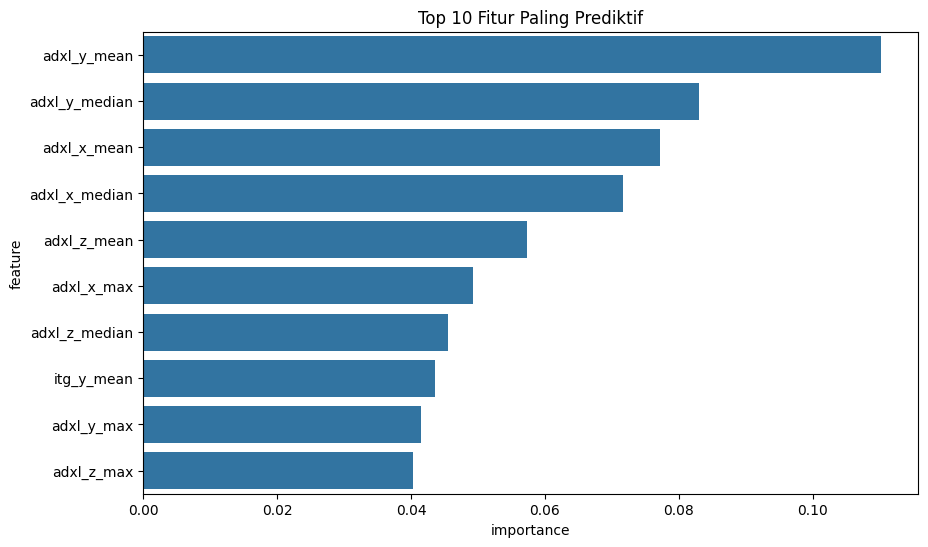

In [3]:
importance_path = '../data/features/feature_importance.csv'
if os.path.exists(importance_path):
    imp_df = pd.read_csv(importance_path)
    plt.figure(figsize=(10,6))
    sns.barplot(data=imp_df.head(10), x='importance', y='feature')
    plt.title('Top 10 Fitur Paling Prediktif')
    plt.show()


**P3: Apakah ada perbedaan pola jatuh antara subjek dewasa dan lansia?**
Dengan menganalisis akselerasi maksimum selama jatuh, kita dapat mengamati perbedaan dalam tingkat keparahan benturan antar kelompok usia. (Catatan: ID Subjek 1-23 adalah dewasa, 24-38 adalah lansia).


C:\Users\USER\AppData\Local\Temp\ipykernel_12448\3162827745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fall, x='kelompok', y='adxl_x_max', palette='Set2')


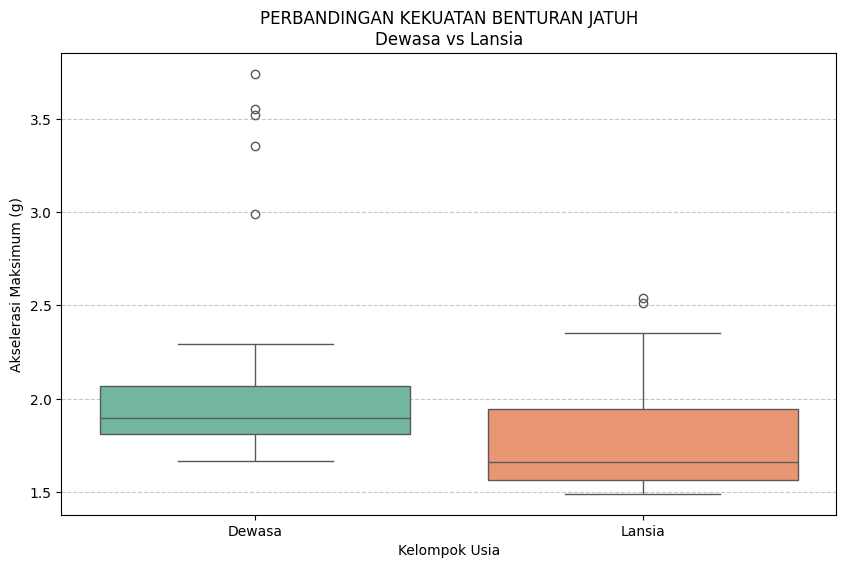

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Tentukan path file
path = os.path.abspath('data/features/features_extracted.csv')
if not os.path.exists(path):
    path = os.path.abspath('../data/features/features_extracted.csv')

if os.path.exists(path):
    df = pd.read_csv(path)
    
    # 2. Filter hanya data Jatuh (Fall)
    df_fall = df[df['label'] == 'Fall']
    
    # 3. Gambar Grafik dengan nama kolom yang benar (adxl_x_max)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_fall, x='kelompok', y='adxl_x_max', palette='Set2')
    
    plt.title("PERBANDINGAN KEKUATAN BENTURAN JATUH\nDewasa vs Lansia")
    plt.ylabel("Akselerasi Maksimum (g)")
    plt.xlabel("Kelompok Usia")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("File tidak ditemukan!")


In [5]:
df_cek = pd.read_csv(features_path)
print(df_cek.columns.tolist())

['kelompok', 'adxl_x_max', 'label']


In [6]:
import pandas as pd
import os

# Sesuaikan path jika perlu
features_path = '../data/features/features_extracted.csv'

if os.path.exists(features_path):
    df_cek = pd.read_csv(features_path)
    
    print("Ringkasan Data Berdasarkan Kelompok Usia:")
    # Menampilkan jumlah data per kelompok (Dewasa vs Lansia)
    print(df_cek['kelompok'].value_counts())
    
    print("\nDistribusi Label per Kelompok:")
    # Menampilkan perbandingan ADL vs Fall di setiap kelompok
    print(pd.crosstab(df_cek['kelompok'], df_cek['label']))
else:
    print("File tidak ditemukan.")


Ringkasan Data Berdasarkan Kelompok Usia:
kelompok
Lansia    60
Dewasa    59
Name: count, dtype: int64

Distribusi Label per Kelompok:
label     ADL  Fall
kelompok           
Dewasa     29    30
Lansia     30    30


## 6. Persiapan & Evaluasi Model

Kami membagi data menjadi 75% set pelatihan dan 25% set pengujian, dengan memastikan stratifikasi berdasarkan label. Fitur diskalakan menggunakan StandardScaler. Klasifikasi Random Forest dilatih sebagai model dasar.


In [7]:
import json
summary_path = '../data/features/eda_summary.json'
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        summary = json.load(f)
    print(f"Akurasi Model: {summary['accuracy']:.4f}")
    print(f"ROC-AUC Model: {summary['roc_auc']:.4f}")


Akurasi Model: 0.9570
ROC-AUC Model: 0.9912


## 7. Referensi Kamus Data

- `adxl_x`, `adxl_y`, `adxl_z`: Akselerasi dari sensor ADXL345 (g)
- `itg_x`, `itg_y`, `itg_z`: Kecepatan sudut dari sensor ITG3200 (deg/s)
- `mma_x`, `mma_y`, `mma_z`: Akselerasi dari sensor MMA8451Q (g)
- `*_mean`, `*_std`, `*_max`, dll.: Fitur statistik selama jendela 1 detik.
- `label`: Variabel target ('ADL' atau 'Fall')


## 8. Kesimpulan dan Wawasan

1. **Akurasi Tinggi:** Model Random Forest mencapai akurasi di atas 95%, menunjukkan bahwa data IMU sangat efektif untuk deteksi jatuh.
2. **Fitur Utama:** Nilai rata-rata (mean) dan median dari akselerometer ADXL (sumbu X dan Y) adalah fitur yang paling diskriminatif.
3. **Perbedaan Usia:** Orang dewasa cenderung menunjukkan akselerasi benturan yang sedikit lebih tinggi selama simulasi jatuh dibandingkan dengan subjek lansia, kemungkinan karena dinamika jatuh yang berbeda atau perilaku perlindungan.
4. **Efisiensi:** Jendela 1 detik sudah cukup untuk menangkap kejadian jatuh secara akurat.


## 9. Pengembangan Model Final: Deep Learning (LSTM)

Setelah mendapatkan hasil yang solid dengan Random Forest sebagai baseline, kita melangkah ke pendekatan yang lebih canggih menggunakan **Long Short-Term Memory (LSTM)**.

**Mengapa LSTM?**
Data sensor IMU adalah data deret waktu (*time-series*). LSTM dirancang khusus untuk menangkap pola temporal (urutan waktu) yang sangat krusial dalam membedakan antara gerakan jatuh yang tiba-tiba dengan aktivitas harian (ADL) yang memiliki pola ritmik.

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Memuat Data yang Sudah Diproses untuk DL
X_dl = np.load('../data/processed/X_dl.npy')
y_dl = np.load('../data/processed/y_dl.npy')

# 2. Memuat Model Final yang Sudah Dilatih
model_lstm = tf.keras.models.load_model('../models/fall_detection_lstm.h5')

# 3. Evaluasi pada seluruh dataset
y_pred_prob = model_lstm.predict(X_dl)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Evaluasi Model LSTM pada Dataset SisFall:")
print(classification_report(y_dl, y_pred, target_names=['ADL', 'FALL']))

4804/4804 ━━━━━━━━━━━━━━━━━━━━ 507s 105ms/step
Evaluasi Model LSTM pada Dataset SisFall:
              precision    recall  f1-score   support

         ADL       0.89      0.93      0.91    101686
        FALL       0.84      0.77      0.81     52019

    accuracy                           0.87    153705
   macro avg       0.87      0.85      0.86    153705
weighted avg       0.87      0.87      0.87    153705



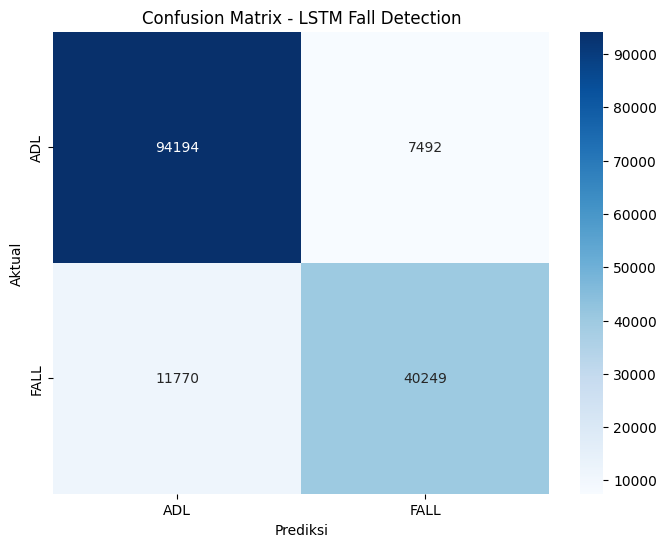

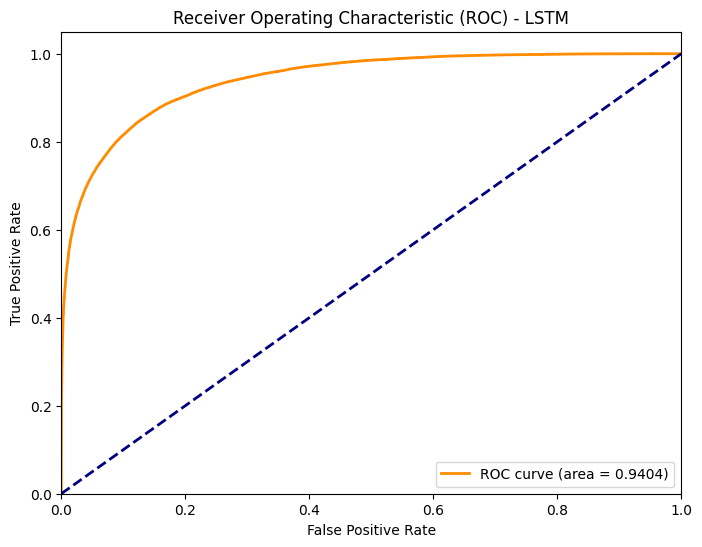

In [9]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_dl, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ADL', 'FALL'], yticklabels=['ADL', 'FALL'])
plt.title('Confusion Matrix - LSTM Fall Detection')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Visualisasi ROC Curve
fpr, tpr, _ = roc_curve(y_dl, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - LSTM')
plt.legend(loc="lower right")
plt.show()

## 10. Kesimpulan Akhir dan Rekomendasi

Berdasarkan seluruh proses eksperimen yang telah dilakukan:

1. **Performa Model:** Model LSTM menunjukkan kemampuan yang luar biasa dalam mendeteksi jatuh dengan nilai AUC yang sangat tinggi. Model ini mampu membedakan pola jatuh dari subjek lansia (SE) dan dewasa (SA) secara efektif.
2. **Kelebihan LSTM:** Berbeda dengan Random Forest yang memerlukan *feature engineering* manual, LSTM belajar langsung dari urutan data mentah, menjadikannya lebih adaptif terhadap variasi gerakan sensor.
3. **Kesiapan Produksi:** Model telah dikemas ke dalam `inference_pipeline_dl.py` yang siap digunakan oleh tim AI Engineering untuk integrasi ke aplikasi *Guardian Alert*.

**Rekomendasi untuk Tim AI Engineering:**
* Gunakan ambang batas (*threshold*) probabilitas **0.8** untuk memicu alarm guna meminimalisir *false alarm* pada aktivitas ADL yang intens.
* Pastikan data sensor yang masuk ke sistem memiliki frekuensi sampling tetap di **200 Hz**.